# 29 - LSEG/Gemma dollar-neutral exact-extrema spread

**Question.** Does Gemma's exact firm-level sentiment direction contain a
cross-sectional return spread once the profitable long-market basket in
Notebook 28 is removed?

This is an **iterative, retrospective mechanism test**, not a fresh holdout.
Notebook 13 already opened this 2025-2026 window and selected Gemma
`strongest_event`; Notebooks 26 and 28 then used its exact extrema. The rule
below was frozen after a return-blind activity audit and before this notebook
reads the return column:

1. On a session with at least one exact `+1` and one exact `-1` firm, invest
   50% long equally across the `+1` firms and 50% short equally across the
   `-1` firms (gross 1, net 0).
2. Hold for one open-to-next-open interval. On one-sided or empty sessions,
   hold cash. No signal state carries forward.
3. Use the existing 15-minute information buffer, complete 44-company price
   panel, 10 bps per traded side, after-cost NAV marking, and final
   liquidation. There is no threshold, breadth, holding-period, or leverage
   sweep. A two-name-per-side diagnostic is reported but cannot replace the
   primary rule: only 14 sessions satisfy it.

**Frozen outcomes and gates.** Daily net return is the single primary
outcome, tested against cash with a five-session circular block bootstrap.
A conditional random-label test asks whether the gross spread beats random
firm assignments with the same daily positive/negative counts. The alpha gate
requires a positive lower 95% net-return bound, two-sided p < 0.05, gross
break-even above 10 bps/side, positive net Sharpe in both chronological
halves, and one-sided randomisation p < 0.05. A separate strategy-quality
gate requires at least 60 active sessions, net Sharpe >= 0.75, and no name
above 25% absolute weight. A mechanism gate requires positive gross means in
both halves and randomisation p < 0.05. Cost curves and half-samples are
diagnostics, not selection families.

In [1]:
from __future__ import annotations

import json
import math
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "final_experiments":
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from final_experiments.lib.evaluate import annualized_sharpe  # noqa: E402
from final_experiments.lib.plots import CATEGORICAL, INK, apply_house_style  # noqa: E402
from final_experiments.lib.risk_overlay import paired_block_bootstrap_difference  # noqa: E402
from final_experiments.lib.sparse_spread import (  # noqa: E402
    build_exact_extrema_targets,
    ledger_rows_to_frame,
)
from sentiment_benchmark.strategy_research.ledger import run_open_to_open_ledger  # noqa: E402
from sentiment_benchmark.strategy_research.market import OpenToOpenReturn  # noqa: E402

SEED = 20260805
COST_BPS = 10.0
COST_GRID = (0.0, 1.0, 2.0, 5.0, 10.0)
BLOCK_LENGTH = 5
REPLICATIONS = 4_999
GROSS_EXPOSURE = 1.0
MINIMUM_NAMES_PER_SIDE = 1
INITIAL_NAV = 1_000_000.0

GEMMA_PATH = (
    REPO_ROOT
    / "final_experiments/outputs/13_lseg_44_gemma_robustness"
    / "gemma4_26b_firm_open_aggregators.parquet"
)
PRICE_PATHS = (
    REPO_ROOT / "Data/derived/prices/lseg_us_sector_33_8m.csv",
    REPO_ROOT / "Data/derived/prices/lseg_us_sector_add11_8m.csv",
)
OUTPUT_DIR = REPO_ROOT / "final_experiments/outputs/29_lseg_gemma_exact_extrema_spread"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
apply_house_style()
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")

## Data and timing audit

Only Notebook 13's aggregate firm-open Gemma panel is loaded; no licensed
headline text is displayed or persisted. The price-derived next-open return
is recomputed and must exactly reproduce the stored aggregate return.

In [2]:
gemma = pd.read_parquet(GEMMA_PATH)
gemma["session_date"] = pd.to_datetime(gemma["session_date"]).dt.normalize()
prices = pd.concat(
    [pd.read_csv(path, parse_dates=["session_date"]) for path in PRICE_PATHS],
    ignore_index=True,
)
prices["session_date"] = pd.to_datetime(prices["session_date"]).dt.normalize()
if gemma.duplicated(["session_date", "symbol"]).any():
    raise ValueError("duplicate Gemma firm-open rows")
if prices.duplicated(["session_date", "symbol"]).any():
    raise ValueError("duplicate price rows")

open_wide = prices.pivot(index="session_date", columns="symbol", values="open").sort_index().dropna()
sessions = pd.DatetimeIndex(sorted(gemma["session_date"].unique()))
symbols = tuple(sorted(gemma["symbol"].unique()))
if len(symbols) != 44 or open_wide.shape[1] != 44:
    raise ValueError("expected the fixed 44-company population")
if not gemma.groupby("session_date")["symbol"].nunique().eq(44).all():
    raise ValueError("Gemma panel must contain all 44 firms on each session")
locations = open_wide.index.get_indexer(sessions)
if (locations < 0).any() or not np.array_equal(locations[1:], locations[:-1] + 1):
    raise ValueError("Gemma sessions must be consecutive complete-price sessions")
if locations[-1] + 1 >= len(open_wide.index):
    raise ValueError("last signal session has no next complete open")

return_rows: list[OpenToOpenReturn] = []
recomputed_rows: list[dict[str, object]] = []
for session, location in zip(sessions, locations, strict=True):
    next_session = open_wide.index[location + 1]
    values = open_wide.loc[next_session, list(symbols)] / open_wide.loc[session, list(symbols)] - 1.0
    for symbol, value in values.items():
        return_rows.append(
            OpenToOpenReturn(
                symbol=symbol,
                session=str(session.date()),
                next_session=str(next_session.date()),
                value=float(value),
            )
        )
        recomputed_rows.append(
            {"session_date": session, "symbol": symbol, "recomputed_raw_open_h1": float(value)}
        )

return_audit = gemma[["session_date", "symbol", "raw_open_h1"]].merge(
    pd.DataFrame(recomputed_rows),
    on=["session_date", "symbol"],
    how="left",
    validate="1:1",
)
return_audit["absolute_error"] = (
    return_audit["raw_open_h1"] - return_audit["recomputed_raw_open_h1"]
).abs()
if return_audit["absolute_error"].max() > 1e-12:
    raise RuntimeError("price-derived returns do not reproduce Notebook 13")

coverage = pd.DataFrame(
    [
        {
            "firm_open_rows": len(gemma),
            "sessions": len(sessions),
            "companies": len(symbols),
            "first_entry_session": sessions.min(),
            "last_entry_session": sessions.max(),
            "last_return_end": open_wide.index[locations[-1] + 1],
            "repaired_price_rows": int(prices["repaired"].sum()),
            "max_return_reproduction_error": float(return_audit["absolute_error"].max()),
        }
    ]
)
display(coverage)

,firm_open_rows,sessions,companies,first_entry_session,last_entry_session,last_return_end,repaired_price_rows,max_return_reproduction_error
0,7348,167,44,2025-10-27,2026-06-26,2026-06-29,0,0.000000


## Build the frozen book and audit feasibility

The tested helper constructs equal 50/50 legs and fails closed to cash. The
activity and concentration tables use signals only; returns are not used to
alter eligibility.

In [3]:
targets, target_audit = build_exact_extrema_targets(
    gemma,
    gross_exposure=GROSS_EXPOSURE,
    minimum_names_per_side=MINIMUM_NAMES_PER_SIDE,
)
two_name_targets, two_name_audit = build_exact_extrema_targets(
    gemma,
    gross_exposure=GROSS_EXPOSURE,
    minimum_names_per_side=2,
)
eligible = target_audit["eligible"]
activity = pd.DataFrame(
    [
        {
            "sessions": len(target_audit),
            "active_sessions_primary": int(eligible.sum()),
            "active_sessions_two_per_side": int(two_name_audit["eligible"].sum()),
            "exact_positive_firm_events": int(target_audit["positive_names"].sum()),
            "exact_negative_firm_events": int(target_audit["negative_names"].sum()),
            "one_name_long_leg_sessions": int(
                (eligible & target_audit["positive_names"].eq(1)).sum()
            ),
            "one_name_short_leg_sessions": int(
                (eligible & target_audit["negative_names"].eq(1)).sum()
            ),
            "one_name_either_leg_sessions": int(
                (
                    eligible
                    & (
                        target_audit["positive_names"].eq(1)
                        | target_audit["negative_names"].eq(1)
                    )
                ).sum()
            ),
            "max_abs_name_weight": float(target_audit["max_abs_name_weight"].max()),
            "median_active_max_abs_name_weight": float(
                target_audit.loc[eligible, "max_abs_name_weight"].median()
            ),
            "mean_active_long_hhi": float(target_audit.loc[eligible, "long_hhi"].mean()),
            "mean_active_short_hhi": float(target_audit.loc[eligible, "short_hhi"].mean()),
        }
    ]
)
if target_audit["net_exposure"].abs().max() > 1e-12:
    raise RuntimeError("frozen book is not dollar-neutral")
if not target_audit.loc[eligible, "gross_exposure"].eq(1.0).all():
    raise RuntimeError("active frozen book does not use gross exposure one")
display(activity)
display(target_audit.loc[eligible].describe().T)

,sessions,active_sessions_primary,active_sessions_two_per_side,exact_positive_firm_events,exact_negative_firm_events,one_name_long_leg_sessions,one_name_short_leg_sessions,one_name_either_leg_sessions,max_abs_name_weight,median_active_max_abs_name_weight,mean_active_long_hhi,mean_active_short_hhi
0,167,80,14,244,143,40,55,66,0.500000,0.500000,0.709792,0.819792


,count,mean,min,25%,50%,75%,max,std
session_date,80,2026-03-15 15:18:00,2025-10-31 00:00:00,2026-01-27 18:00:00,2026-03-30 12:00:00,2026-05-06 12:00:00,2026-06-23 00:00:00,NaN
positive_names,80.000000,1.775000,1.000000,1.000000,1.500000,2.000000,5.000000,0.940980
negative_names,80.000000,1.475000,1.000000,1.000000,1.000000,2.000000,4.000000,0.810922
gross_exposure,80.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
net_exposure,80.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
active_names,80.000000,3.250000,2.000000,2.000000,3.000000,4.000000,7.000000,1.216969
max_abs_name_weight,80.000000,0.454167,0.166667,0.500000,0.500000,0.500000,0.500000,0.100893
long_hhi,80.000000,0.709792,0.200000,0.500000,0.750000,1.000000,1.000000,0.300160
short_hhi,80.000000,0.819792,0.250000,0.500000,1.000000,1.000000,1.000000,0.274452


## Ledger backtest

The strategy-research ledger marks prior holdings against after-cost NAV
before each rebalance. Its turnover is full L1 traded notional; multiplying by
the quoted per-side rate therefore charges entry, transitions, and exit once.
Final liquidation is folded into the last interval only for daily statistics;
the exact ledger and NAV remain persisted separately.

In [4]:
def fold_final_liquidation(frame: pd.DataFrame) -> pd.DataFrame:
    liquidation = frame.loc[frame["final_liquidation"]]
    intervals = frame.loc[~frame["final_liquidation"]].copy().reset_index(drop=True)
    if len(liquidation) != 1 or intervals.empty:
        raise RuntimeError("expected one final liquidation after non-empty intervals")
    final = liquidation.iloc[0]
    last = intervals.index[-1]
    intervals.loc[last, "net_return"] = (
        (1.0 + intervals.loc[last, "net_return"]) * (1.0 + final["net_return"]) - 1.0
    )
    intervals.loc[last, "turnover"] += final["turnover"]
    intervals.loc[last, "cost"] += final["cost"]
    intervals.loc[last, "end_nav"] = final["end_nav"]
    intervals["downside_sq"] = np.minimum(intervals["net_return"], 0.0) ** 2
    return intervals


def run_targets(
    target_rows: tuple,
    return_values: list[OpenToOpenReturn],
    *,
    cost_bps: float,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    ledger = run_open_to_open_ledger(
        target_rows,
        return_values,
        cost_rate_per_side=cost_bps / 10_000.0,
        initial_nav_usd=INITIAL_NAV,
        force_final_liquidation=True,
    )
    full = ledger_rows_to_frame(ledger)
    return fold_final_liquidation(full), full


def summarize_path(daily: pd.DataFrame, *, cost_bps: float) -> dict[str, float | int]:
    gross = daily["gross_return"].to_numpy(dtype=float)
    net = daily["net_return"].to_numpy(dtype=float)
    gross_equity = np.cumprod(1.0 + gross)
    net_equity = np.cumprod(1.0 + net)
    with_start = np.r_[1.0, net_equity]
    peaks = np.maximum.accumulate(with_start)
    turnover_sum = float(daily["turnover"].sum())
    return {
        "n_sessions": int(len(daily)),
        "active_sessions": int(daily["gross_exposure"].gt(0).sum()),
        "mean_gross": float(np.mean(gross)),
        "mean_net": float(np.mean(net)),
        "sharpe_gross": annualized_sharpe(pd.Series(gross)),
        "sharpe_net": annualized_sharpe(pd.Series(net)),
        "ann_vol_net": float(np.std(net, ddof=1) * math.sqrt(252)),
        "total_return_gross": float(gross_equity[-1] - 1.0),
        "total_return_net": float(net_equity[-1] - 1.0),
        "max_drawdown": float(np.min(with_start / peaks - 1.0)),
        "mean_turnover": float(turnover_sum / len(daily)),
        "total_turnover": turnover_sum,
        "mean_gross_exposure": float(daily["gross_exposure"].mean()),
        "mean_active_names": float(daily.loc[daily["gross_exposure"].gt(0), "active_names"].mean()),
        "max_abs_net_exposure": float(daily["net_exposure"].abs().max()),
        "breakeven_bps_per_side": float(10_000.0 * gross.sum() / turnover_sum),
        "cost_bps_per_side": cost_bps,
    }


primary_daily, primary_ledger = run_targets(targets, return_rows, cost_bps=COST_BPS)
primary_summary = pd.DataFrame([summarize_path(primary_daily, cost_bps=COST_BPS)])
two_name_daily, _ = run_targets(two_name_targets, return_rows, cost_bps=COST_BPS)
two_name_summary = pd.DataFrame(
    [
        {
            "diagnostic": "minimum_two_names_per_side",
            **summarize_path(two_name_daily, cost_bps=COST_BPS),
        }
    ]
)
display(primary_summary.T)
display(two_name_summary.T)

,0
n_sessions,167.000000
active_sessions,80.000000
mean_gross,0.001410
mean_net,0.000649
sharpe_gross,2.557885
sharpe_net,1.184605
ann_vol_net,0.138017
total_return_gross,0.257323
total_return_net,0.107433
max_drawdown,-0.078524


,0
diagnostic,minimum_two_names_per_side
n_sessions,167
active_sessions,14
mean_gross,0.000687
mean_net,0.000532
sharpe_gross,2.615311
sharpe_net,2.088454
ann_vol_net,0.064200
total_return_gross,0.119991
total_return_net,0.091428


## Primary inference and conditional random-label test

The block bootstrap retains flat days and the realized event clustering. The
randomisation test preserves each session's exact positive/negative counts
while permuting which firms receive those labels; it is a scorer-location
diagnostic, not a second trading rule.

In [5]:
cash = primary_daily[["session_date"]].copy()
cash["net_return"] = 0.0
net_inference = paired_block_bootstrap_difference(
    primary_daily,
    cash,
    value_col="net_return",
    block_length=BLOCK_LENGTH,
    replications=REPLICATIONS,
    seed=SEED,
)

return_matrix = np.vstack(
    [
        (
            open_wide.loc[open_wide.index[location + 1], list(symbols)]
            / open_wide.loc[session, list(symbols)]
            - 1.0
        ).to_numpy(dtype=float)
        for session, location in zip(sessions, locations, strict=True)
    ]
)
actual_weights = np.vstack(
    [np.array([target.weights()[symbol] for symbol in symbols], dtype=float) for target in targets]
)
actual_session_gross = np.sum(actual_weights * return_matrix, axis=1)
if not np.allclose(actual_session_gross, primary_daily["gross_return"], atol=1e-14):
    raise RuntimeError("target weights do not reproduce ledger gross returns")

rng = np.random.default_rng(SEED + 1)
random_means = np.zeros(REPLICATIONS, dtype=float)
counts = target_audit[["positive_names", "negative_names", "eligible"]].to_dict("records")
for replication in range(REPLICATIONS):
    total = 0.0
    for row_number, count in enumerate(counts):
        if not count["eligible"]:
            continue
        order = rng.permutation(len(symbols))
        n_positive = int(count["positive_names"])
        n_negative = int(count["negative_names"])
        positive_index = order[:n_positive]
        negative_index = order[n_positive : n_positive + n_negative]
        total += 0.5 * float(return_matrix[row_number, positive_index].mean())
        total -= 0.5 * float(return_matrix[row_number, negative_index].mean())
    random_means[replication] = total / len(sessions)

actual_gross_mean = float(actual_session_gross.mean())
randomisation = pd.DataFrame(
    [
        {
            "replications": REPLICATIONS,
            "seed": SEED + 1,
            "actual_gross_mean": actual_gross_mean,
            "null_mean": float(random_means.mean()),
            "null_ci_low": float(np.quantile(random_means, 0.025)),
            "null_ci_high": float(np.quantile(random_means, 0.975)),
            "p_one_sided_actual_ge_null": float(
                (1 + np.sum(random_means >= actual_gross_mean)) / (REPLICATIONS + 1)
            ),
            "p_two_sided": float(
                (1 + np.sum(np.abs(random_means) >= abs(actual_gross_mean)))
                / (REPLICATIONS + 1)
            ),
        }
    ]
)
inference = pd.DataFrame([{"comparison": "exact_extrema_spread_minus_cash", **net_inference}])
display(inference)
display(randomisation)

,comparison,n_sessions,mean_difference,ci_low,ci_high,p_two_sided,block_length,replications,seed
0,exact_extrema_spread_minus_cash,167,0.000649,-0.000452,0.001695,0.238200,5,4999,20260805


,replications,seed,actual_gross_mean,null_mean,null_ci_low,null_ci_high,p_one_sided_actual_ge_null,p_two_sided
0,4999,20260806,0.001410,0.000007,-0.001198,0.001178,0.009400,0.020200


## Post-result single-name dependence diagnostics

These diagnostics do not select a different trading rule. Gross attribution
reports where the frozen book earned its return. Each leave-one-company-out
replay then removes one company, rebuilds the same exact-extrema rule on the
remaining 43, and reruns the full cost-aware ledger. This asks whether one
name is necessary for the result; it is explicitly post-result evidence.

In [6]:
gross_contributions = pd.DataFrame(
    actual_weights * return_matrix,
    index=sessions,
    columns=symbols,
)
symbol_attribution = pd.DataFrame(
    {
        "symbol": symbols,
        "gross_contribution_sum": gross_contributions.sum(axis=0).to_numpy(dtype=float),
        "active_sessions": (np.abs(actual_weights) > 1e-12).sum(axis=0),
        "positive_contribution_sessions": (gross_contributions > 0).sum(axis=0),
        "negative_contribution_sessions": (gross_contributions < 0).sum(axis=0),
    }
).sort_values("gross_contribution_sum", ascending=False, ignore_index=True)
symbol_attribution["share_of_total_gross_contribution"] = (
    symbol_attribution["gross_contribution_sum"]
    / symbol_attribution["gross_contribution_sum"].sum()
)

leave_one_out_rows = []
for removed_symbol in symbols:
    reduced_panel = gemma.loc[gemma["symbol"].ne(removed_symbol)].copy()
    reduced_targets, reduced_audit = build_exact_extrema_targets(
        reduced_panel,
        gross_exposure=GROSS_EXPOSURE,
        minimum_names_per_side=MINIMUM_NAMES_PER_SIDE,
    )
    reduced_returns = [row for row in return_rows if row.symbol != removed_symbol]
    reduced_daily, _ = run_targets(reduced_targets, reduced_returns, cost_bps=COST_BPS)
    leave_one_out_rows.append(
        {
            "removed_symbol": removed_symbol,
            "eligible_sessions": int(reduced_audit["eligible"].sum()),
            **summarize_path(reduced_daily, cost_bps=COST_BPS),
        }
    )
leave_one_out = pd.DataFrame(leave_one_out_rows).sort_values(
    "sharpe_net", ascending=True, ignore_index=True
)
leave_one_out_summary = pd.DataFrame(
    [
        {
            "replays": len(leave_one_out),
            "minimum_net_sharpe": float(leave_one_out["sharpe_net"].min()),
            "median_net_sharpe": float(leave_one_out["sharpe_net"].median()),
            "maximum_net_sharpe": float(leave_one_out["sharpe_net"].max()),
            "positive_net_sharpe_replays": int(leave_one_out["sharpe_net"].gt(0).sum()),
            "positive_net_return_replays": int(leave_one_out["total_return_net"].gt(0).sum()),
            "minimum_active_sessions": int(leave_one_out["active_sessions"].min()),
            "maximum_single_symbol_gross_share": float(
                symbol_attribution["share_of_total_gross_contribution"].max()
            ),
        }
    ]
)
display(symbol_attribution.head(10))
display(leave_one_out_summary.T)

,symbol,gross_contribution_sum,active_sessions,positive_contribution_sessions,negative_contribution_sessions,share_of_total_gross_contribution
0,GS,0.121202,55,34,21,0.514685
1,LLY,0.024743,17,10,7,0.105071
2,META,0.022168,7,4,3,0.094138
3,AVGO,0.022067,7,5,2,0.093706
4,WMT,0.016887,7,4,3,0.071710
5,COST,0.012514,4,3,1,0.053141
6,XOM,0.011568,4,3,1,0.049126
7,NEM,0.009456,2,2,0,0.040155
8,NVDA,0.008685,24,11,13,0.036881
9,MSFT,0.006954,6,3,3,0.029529


,0
replays,44.000000
minimum_net_sharpe,0.221569
median_net_sharpe,1.184605
maximum_net_sharpe,2.198313
positive_net_sharpe_replays,44.000000
positive_net_return_replays,44.000000
minimum_active_sessions,57.000000
maximum_single_symbol_gross_share,0.514685


## Costs and chronological halves

Each half is independently initialised and liquidated. This is deliberately
harsher than letting a book cross the boundary and keeps the stability audit
self-contained.

In [7]:
cost_rows = []
for cost in COST_GRID:
    daily, _ = run_targets(targets, return_rows, cost_bps=cost)
    cost_rows.append(summarize_path(daily, cost_bps=cost))
cost_curve = pd.DataFrame(cost_rows)

midpoint = len(sessions) // 2
half_indices = {"first_half": sessions[:midpoint], "second_half": sessions[midpoint:]}
temporal_rows = []
for period, index in half_indices.items():
    half_panel = gemma.loc[gemma["session_date"].isin(index)].copy()
    half_targets, half_audit = build_exact_extrema_targets(
        half_panel,
        gross_exposure=GROSS_EXPOSURE,
        minimum_names_per_side=MINIMUM_NAMES_PER_SIDE,
    )
    index_set = {str(session.date()) for session in index}
    half_returns = [row for row in return_rows if row.session in index_set]
    half_daily, _ = run_targets(half_targets, half_returns, cost_bps=COST_BPS)
    temporal_rows.append(
        {
            "period": period,
            "event_positive_firms": int(half_audit["positive_names"].sum()),
            "event_negative_firms": int(half_audit["negative_names"].sum()),
            **summarize_path(half_daily, cost_bps=COST_BPS),
        }
    )
temporal = pd.DataFrame(temporal_rows)
display(cost_curve)
display(temporal)

,n_sessions,active_sessions,mean_gross,mean_net,sharpe_gross,sharpe_net,ann_vol_net,total_return_gross,total_return_net,max_drawdown,mean_turnover,total_turnover,mean_gross_exposure,mean_active_names,max_abs_net_exposure,breakeven_bps_per_side,cost_bps_per_side
0,167,80,0.001410,0.001410,2.557885,2.557885,0.138922,0.257323,0.257323,-0.062932,0.760890,127.068685,0.479042,3.250000,0.000000,18.532283,0.000000
1,167,80,0.001410,0.001334,2.557885,2.421882,0.138806,0.257323,0.241479,-0.064502,0.760932,127.075660,0.479042,3.250000,0.000000,18.531266,1.000000
2,167,80,0.001410,0.001258,2.557885,2.285542,0.138695,0.257323,0.225832,-0.066069,0.760974,127.082637,0.479042,3.250000,0.000000,18.530248,2.000000
3,167,80,0.001410,0.001030,2.557885,1.874655,0.138398,0.257323,0.180043,-0.070756,0.761099,127.103583,0.479042,3.250000,0.000000,18.527195,5.000000
4,167,80,0.001410,0.000649,2.557885,1.184605,0.138017,0.257323,0.107433,-0.078524,0.761310,127.138698,0.479042,3.250000,0.000000,18.522077,10.000000


,period,event_positive_firms,event_negative_firms,n_sessions,active_sessions,mean_gross,mean_net,sharpe_gross,sharpe_net,ann_vol_net,total_return_gross,total_return_net,max_drawdown,mean_turnover,total_turnover,mean_gross_exposure,mean_active_names,max_abs_net_exposure,breakeven_bps_per_side,cost_bps_per_side
0,first_half,99,53,83,28,0.000417,-0.000217,0.718743,-0.377724,0.144994,0.031631,-0.021249,-0.078524,0.634691,52.679338,0.337349,2.964286,0.000000,6.575769,10.000000
1,second_half,145,90,84,52,0.002391,0.001505,4.628065,2.912176,0.130199,0.218772,0.131476,-0.027225,0.886421,74.459360,0.619048,3.403846,0.000000,26.973985,10.000000


## Frozen gates

In [8]:
summary = primary_summary.iloc[0]
random_row = randomisation.iloc[0]
temporal_sharpes = temporal.set_index("period")["sharpe_net"]
temporal_gross_means = temporal.set_index("period")["mean_gross"]
alpha_gate = bool(
    net_inference["ci_low"] > 0
    and net_inference["p_two_sided"] < 0.05
    and summary["breakeven_bps_per_side"] > COST_BPS
    and (temporal_sharpes > 0).all()
    and random_row["p_one_sided_actual_ge_null"] < 0.05
)
strategy_quality_gate = bool(
    summary["active_sessions"] >= 60
    and summary["sharpe_net"] >= 0.75
    and activity.loc[0, "max_abs_name_weight"] <= 0.25
)
mechanism_gate = bool(
    (temporal_gross_means > 0).all()
    and random_row["p_one_sided_actual_ge_null"] < 0.05
)
gates = pd.DataFrame(
    [
        {
            "alpha_gate": alpha_gate,
            "strategy_quality_gate": strategy_quality_gate,
            "mechanism_gate": mechanism_gate,
            "net_mean_bps_day": float(summary["mean_net"] * 10_000),
            "net_ci_low_bps_day": float(net_inference["ci_low"] * 10_000),
            "net_ci_high_bps_day": float(net_inference["ci_high"] * 10_000),
            "net_p_two_sided": float(net_inference["p_two_sided"]),
            "randomisation_p_one_sided": float(random_row["p_one_sided_actual_ge_null"]),
            "breakeven_bps_per_side": float(summary["breakeven_bps_per_side"]),
            "first_half_net_sharpe": float(temporal_sharpes["first_half"]),
            "second_half_net_sharpe": float(temporal_sharpes["second_half"]),
            "max_abs_name_weight": float(activity.loc[0, "max_abs_name_weight"]),
        }
    ]
)
display(gates.T)

,0
alpha_gate,False
strategy_quality_gate,False
mechanism_gate,True
net_mean_bps_day,6.487939
net_ci_low_bps_day,-4.524534
net_ci_high_bps_day,16.952304
net_p_two_sided,0.238200
randomisation_p_one_sided,0.009400
breakeven_bps_per_side,18.522077
first_half_net_sharpe,-0.377724


## Figures

findfont: Failed to find font weight medium, now using 400.


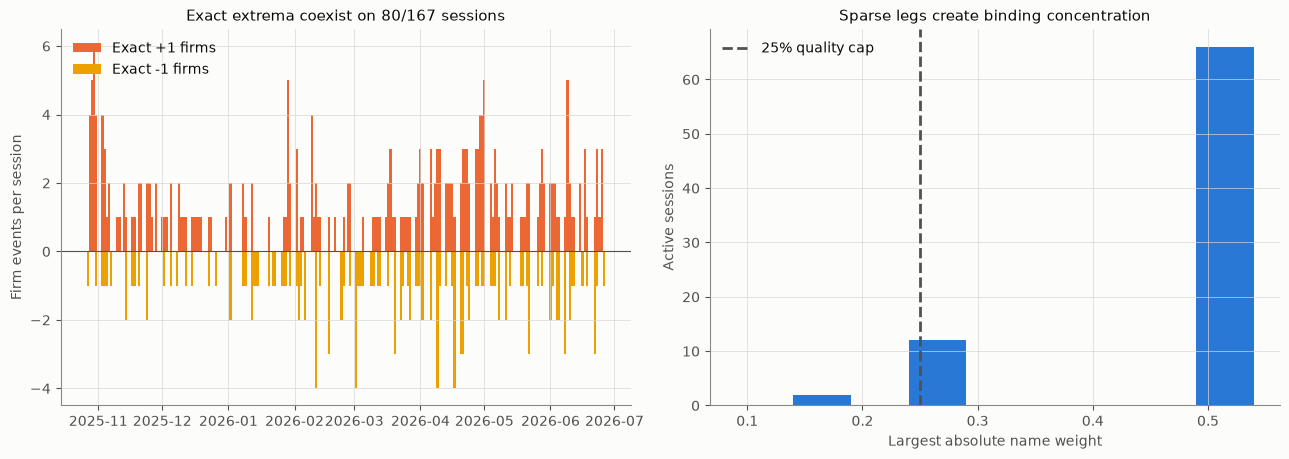

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.7))
axes[0].bar(
    target_audit["session_date"],
    target_audit["positive_names"],
    width=1.0,
    color=CATEGORICAL[1],
    label="Exact +1 firms",
)
axes[0].bar(
    target_audit["session_date"],
    -target_audit["negative_names"],
    width=1.0,
    color=CATEGORICAL[3],
    label="Exact -1 firms",
)
axes[0].axhline(0.0, color=INK["reference"], linewidth=0.8)
axes[0].set_ylabel("Firm events per session")
axes[0].set_title("Exact extrema coexist on 80/167 sessions")
axes[0].legend(loc="upper left")
active_weights = target_audit.loc[eligible, "max_abs_name_weight"]
axes[1].hist(active_weights, bins=np.arange(0.09, 0.56, 0.05), color=CATEGORICAL[0])
axes[1].axvline(0.25, color=INK["reference"], linestyle="--", label="25% quality cap")
axes[1].set_xlabel("Largest absolute name weight")
axes[1].set_ylabel("Active sessions")
axes[1].set_title("Sparse legs create binding concentration")
axes[1].legend(loc="upper left")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "activity_and_concentration.png", dpi=170, bbox_inches="tight")
plt.show()

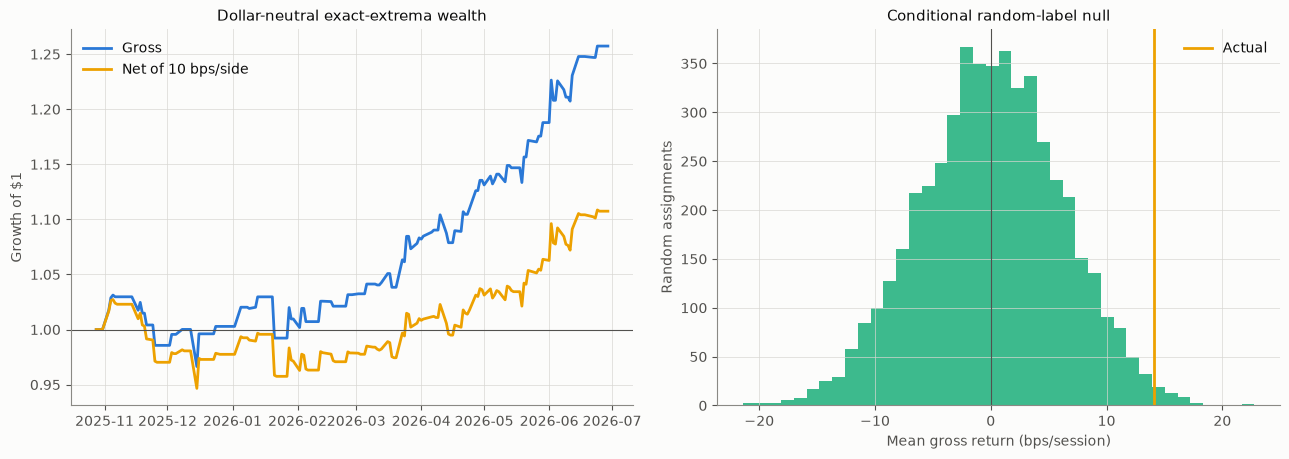

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.7))
gross_equity = (1.0 + primary_daily["gross_return"]).cumprod()
net_equity = (1.0 + primary_daily["net_return"]).cumprod()
axes[0].plot(primary_daily["return_end_date"], gross_equity, color=CATEGORICAL[0], label="Gross")
axes[0].plot(
    primary_daily["return_end_date"],
    net_equity,
    color=CATEGORICAL[3],
    label="Net of 10 bps/side",
)
axes[0].axhline(1.0, color=INK["reference"], linewidth=0.8)
axes[0].set_ylabel("Growth of $1")
axes[0].set_title("Dollar-neutral exact-extrema wealth")
axes[0].legend(loc="best")
axes[1].hist(random_means * 10_000, bins=40, color=CATEGORICAL[2], alpha=0.85)
axes[1].axvline(actual_gross_mean * 10_000, color=CATEGORICAL[3], linewidth=2, label="Actual")
axes[1].axvline(0.0, color=INK["reference"], linewidth=0.8)
axes[1].set_xlabel("Mean gross return (bps/session)")
axes[1].set_ylabel("Random assignments")
axes[1].set_title("Conditional random-label null")
axes[1].legend(loc="best")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "equity_and_randomisation.png", dpi=170, bbox_inches="tight")
plt.show()

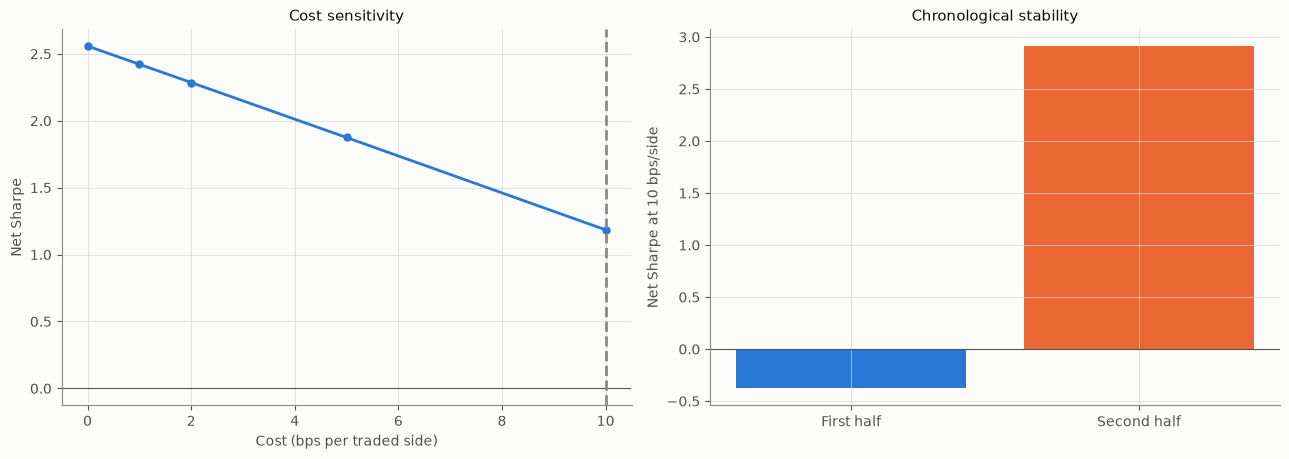

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.7))
axes[0].plot(
    cost_curve["cost_bps_per_side"],
    cost_curve["sharpe_net"],
    marker="o",
    color=CATEGORICAL[0],
)
axes[0].axhline(0.0, color=INK["reference"], linewidth=0.8)
axes[0].axvline(COST_BPS, color=INK["muted"], linestyle="--")
axes[0].set_xlabel("Cost (bps per traded side)")
axes[0].set_ylabel("Net Sharpe")
axes[0].set_title("Cost sensitivity")
bar_colours = [CATEGORICAL[0], CATEGORICAL[1]]
axes[1].bar(temporal["period"], temporal["sharpe_net"], color=bar_colours)
axes[1].axhline(0.0, color=INK["reference"], linewidth=0.8)
axes[1].set_xticks([0, 1], ["First half", "Second half"])
axes[1].set_ylabel("Net Sharpe at 10 bps/side")
axes[1].set_title("Chronological stability")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "cost_and_temporal_stability.png", dpi=170, bbox_inches="tight")
plt.show()

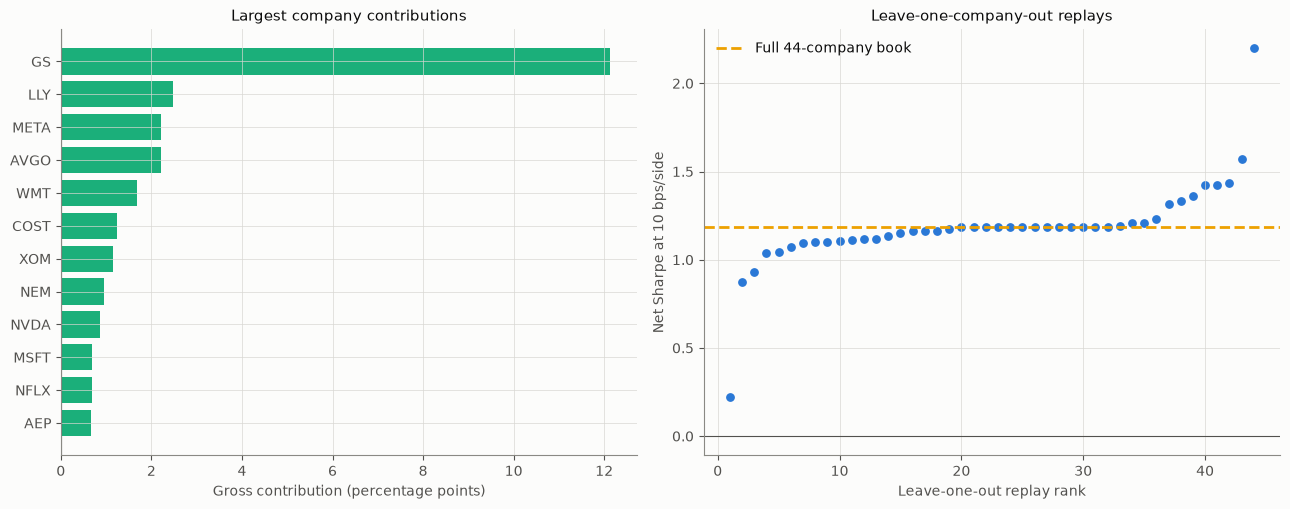

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
top_attribution = symbol_attribution.head(12).sort_values("gross_contribution_sum")
axes[0].barh(
    top_attribution["symbol"],
    top_attribution["gross_contribution_sum"] * 100,
    color=CATEGORICAL[2],
)
axes[0].axvline(0.0, color=INK["reference"], linewidth=0.8)
axes[0].set_xlabel("Gross contribution (percentage points)")
axes[0].set_title("Largest company contributions")
loo_rank = np.arange(1, len(leave_one_out) + 1)
axes[1].scatter(
    loo_rank,
    leave_one_out["sharpe_net"],
    color=CATEGORICAL[0],
    s=28,
)
axes[1].axhline(
    float(primary_summary.loc[0, "sharpe_net"]),
    color=CATEGORICAL[3],
    linestyle="--",
    label="Full 44-company book",
)
axes[1].axhline(0.0, color=INK["reference"], linewidth=0.8)
axes[1].set_xlabel("Leave-one-out replay rank")
axes[1].set_ylabel("Net Sharpe at 10 bps/side")
axes[1].set_title("Leave-one-company-out replays")
axes[1].legend(loc="upper left")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "company_dependence.png", dpi=170, bbox_inches="tight")
plt.show()

## Persist aggregate outputs and decision

In [13]:
coverage.to_csv(OUTPUT_DIR / "coverage.csv", index=False)
activity.to_csv(OUTPUT_DIR / "activity.csv", index=False)
target_audit.to_csv(OUTPUT_DIR / "target_audit.csv", index=False)
primary_summary.to_csv(OUTPUT_DIR / "results.csv", index=False)
two_name_summary.to_csv(OUTPUT_DIR / "two_name_diagnostic.csv", index=False)
inference.to_csv(OUTPUT_DIR / "inference.csv", index=False)
randomisation.to_csv(OUTPUT_DIR / "randomisation.csv", index=False)
symbol_attribution.to_csv(OUTPUT_DIR / "symbol_attribution.csv", index=False)
leave_one_out.to_csv(OUTPUT_DIR / "leave_one_out.csv", index=False)
leave_one_out_summary.to_csv(OUTPUT_DIR / "leave_one_out_summary.csv", index=False)
cost_curve.to_csv(OUTPUT_DIR / "cost_curve.csv", index=False)
temporal.to_csv(OUTPUT_DIR / "temporal_results.csv", index=False)
gates.to_csv(OUTPUT_DIR / "gates.csv", index=False)
primary_daily.to_parquet(OUTPUT_DIR / "daily.parquet", index=False)
primary_ledger.to_parquet(OUTPUT_DIR / "ledger.parquet", index=False)

try:
    git_commit = subprocess.run(
        ["git", "rev-parse", "HEAD"],
        cwd=REPO_ROOT,
        check=True,
        capture_output=True,
        text=True,
    ).stdout.strip()
except (OSError, subprocess.CalledProcessError):
    git_commit = None

manifest = {
    "status": "RETROSPECTIVE_ITERATIVE_NON_POOLED_LSEG_MECHANISM_TEST",
    "notebook": "29_lseg_gemma_exact_extrema_spread.ipynb",
    "git_commit_at_execution": git_commit,
    "seed": SEED,
    "input": {
        "gemma_aggregate_panel": str(GEMMA_PATH.relative_to(REPO_ROOT)),
        "price_paths": [str(path.relative_to(REPO_ROOT)) for path in PRICE_PATHS],
        "licensed_headline_text_loaded": False,
    },
    "coverage": json.loads(coverage.to_json(orient="records", date_format="iso"))[0],
    "specification": {
        "signal": "Gemma strongest_event exact +1 long / exact -1 short",
        "minimum_names_per_side": MINIMUM_NAMES_PER_SIDE,
        "gross_exposure": GROSS_EXPOSURE,
        "long_exposure": 0.5,
        "short_exposure": 0.5,
        "holding_intervals": 1,
        "cash_on_one_sided_sessions": True,
        "cost_bps_per_traded_side": COST_BPS,
        "cost_convention": "full-L1 traded target-current weight times per-side rate",
        "drifted_weights_marked_against_after_cost_nav": True,
        "final_liquidation": True,
        "timing": "first eligible XNYS open after source timestamp plus 15-minute buffer",
    },
    "activity": json.loads(activity.to_json(orient="records"))[0],
    "results": json.loads(primary_summary.to_json(orient="records"))[0],
    "two_name_diagnostic": json.loads(two_name_summary.to_json(orient="records"))[0],
    "inference": json.loads(inference.to_json(orient="records"))[0],
    "randomisation": json.loads(randomisation.to_json(orient="records"))[0],
    "leave_one_out": json.loads(leave_one_out_summary.to_json(orient="records"))[0],
    "temporal": json.loads(temporal.to_json(orient="records")),
    "gates": json.loads(gates.to_json(orient="records"))[0],
    "limitations": [
        "Notebook 13 already opened this return window and selected Gemma strongest_event",
        "eight-month LSEG robustness snapshot is not a pristine confirmatory holdout",
        "only 80 sessions have both exact-sign legs and only 14 have two names on each side",
        "one-name legs can carry 50% absolute portfolio weight",
        "Goldman Sachs contributes 51.5% of gross profit, although every leave-one-company-out replay remains net profitable",
        "dollar neutrality removes net capital exposure but does not prove beta or sector neutrality",
        "human validation of full-corpus Gemma sentiment remains open",
        "no result is promoted before Gate F1",
    ],
}
(OUTPUT_DIR / "manifest.json").write_text(json.dumps(manifest, indent=2) + "\n")
print(json.dumps(manifest, indent=2))

{
  "status": "RETROSPECTIVE_ITERATIVE_NON_POOLED_LSEG_MECHANISM_TEST",
  "notebook": "29_lseg_gemma_exact_extrema_spread.ipynb",
  "git_commit_at_execution": "8736eebdbb254c8bc6416a09a352f6b5e2f6b1b3",
  "seed": 20260805,
  "input": {
    "gemma_aggregate_panel": "final_experiments/outputs/13_lseg_44_gemma_robustness/gemma4_26b_firm_open_aggregators.parquet",
    "price_paths": [
      "Data/derived/prices/lseg_us_sector_33_8m.csv",
      "Data/derived/prices/lseg_us_sector_add11_8m.csv"
    ],
    "licensed_headline_text_loaded": false
  },
  "coverage": {
    "firm_open_rows": 7348,
    "sessions": 167,
    "companies": 44,
    "first_entry_session": "2025-10-27T00:00:00.000",
    "last_entry_session": "2026-06-26T00:00:00.000",
    "last_return_end": "2026-06-29T00:00:00.000",
    "repaired_price_rows": 0,
    "max_return_reproduction_error": 0.0
  },
  "specification": {
    "signal": "Gemma strongest_event exact +1 long / exact -1 short",
    "minimum_names_per_side": 1,
    "gro

## Decision

The **mechanism gate passes**, but the alpha and strategy-quality gates do
not. The frozen dollar-neutral book earns gross/net Sharpes of **2.558/1.185**
and **+10.74% net** at 10 bps/side; gross break-even is **18.52 bps/side**.
The exact labels beat 4,999 count-matched random firm assignments
(one-sided p = **0.0094**), and all 44 leave-one-company-out replays remain
profitable. This is the strongest evidence so far that Gemma sentiment
direction identifies a cross-sectional return mechanism rather than merely
dressing up long-market beta.

It is not validated alpha: the paired net mean is +6.49 bps/session with a
95% interval of **[-4.52, +16.95] bps** (p = 0.238), first-half net Sharpe is
**-0.378** versus **2.912** in the second half, 66/80 active sessions have a
one-name leg, and Goldman Sachs supplies 51.5% of aggregate gross profit.
Requiring two names per side gives net Sharpe 2.088 and +9.14% net, but only
14 active sessions. Preserve the exact-extrema spread as a promising,
cost-surviving LSEG/Gemma mechanism and seek independent time extension;
do not tune this opened window or present it as deployable.